In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import random

# =========================================================
# Setup
# =========================================================
ROOT = Path("..")
DATA_ROOT = ROOT / "data"

HAM_DIR = DATA_ROOT / "HAM10000"
HAM_CSV = HAM_DIR / "HAM10000.csv"
IMAGE_DIR = HAM_DIR / "images"   # change if needed
MASK_DIR = DATA_ROOT / "HAM10000_segmentations_lesion_tschandl"

print("HAM_CSV  :", HAM_CSV, "| exists:", HAM_CSV.exists())
print("IMAGE_DIR:", IMAGE_DIR, "| exists:", IMAGE_DIR.exists())
print("MASK_DIR :", MASK_DIR, "| exists:", MASK_DIR.exists())

# =========================================================
# Load original HAM csv
# =========================================================
ham_df = pd.read_csv(HAM_CSV)
print("\nLoaded HAM CSV")
print("Shape:", ham_df.shape)
print("Columns:", list(ham_df.columns))

required_cols = ["image_id", "label", "dx", "split", "image"]
missing = [c for c in required_cols if c not in ham_df.columns]
if missing:
    raise ValueError(f"Missing required columns in HAM CSV: {missing}")

# clean split typo if present
ham_df["split"] = ham_df["split"].replace({"trainisic": "train"})

# =========================================================
# Build segmentation index directly from mask folder
# =========================================================
suffix = "_segmentation.png"
mask_rows = []

pngs = sorted(MASK_DIR.glob("*.png"))
print("\nFound segmentation pngs:", len(pngs))

for p in pngs:
    fname = p.name
    if fname.endswith(suffix):
        image_id = fname[:-len(suffix)]
    else:
        image_id = p.stem

    mask_rows.append({
        "image_id": image_id,
        "mask_filename": fname,
    })

mask_df = pd.DataFrame(mask_rows)

print("Indexed masks:", len(mask_df))
print("Unique image_ids in mask folder:", mask_df["image_id"].nunique())

dups = mask_df[mask_df.duplicated(subset=["image_id"], keep=False)]
print("Duplicate image_ids in mask folder:", len(dups))

# =========================================================
# Merge HAM CSV with mask index
# =========================================================
df = ham_df.merge(mask_df, on="image_id", how="left")
df["mask_found"] = df["mask_filename"].notna().astype(int)

# relative paths only
df["image_rel_path"] = "images/" + df["image"].astype(str)
df["mask_rel_path"] = "../HAM10000_segmentations_lesion_tschandl/" + df["mask_filename"].astype(str)

# absolute paths only for runtime checks
df["image_abs_path"] = df["image_rel_path"].apply(lambda x: (HAM_DIR / x).resolve())
df["mask_abs_path"] = df["mask_rel_path"].apply(lambda x: (HAM_DIR / x).resolve())

# =========================================================
# Keep only requested columns and save overlap CSV
# =========================================================
final_cols = [
    "image_id",
    "label",
    "dx",
    "split",
    "image_rel_path",
    "mask_rel_path",
    "mask_found",
]

final_df = df[final_cols].copy()

out_dir = ROOT / "data" / "HAM10000"
out_dir.mkdir(parents=True, exist_ok=True)

overlap_csv_path = out_dir / "ham_segmentation_overlap.csv"
final_df.to_csv(overlap_csv_path, index=False)

print("\nSaved overlap CSV:", overlap_csv_path)
display(final_df.head())

# =========================================================
# 1) Coverage per split
# =========================================================
coverage = (
    final_df.groupby("split", dropna=False)
    .agg(
        total_images=("image_id", "count"),
        masks_found=("mask_found", "sum")
    )
    .reset_index()
)
coverage["coverage_pct"] = (100 * coverage["masks_found"] / coverage["total_images"]).round(2)

# =========================================================
# 2) No accidental missing files
# =========================================================
df["image_exists"] = df["image_abs_path"].apply(lambda p: Path(p).exists())
df["mask_exists"] = df["mask_abs_path"].apply(lambda p: Path(p).exists())

exist_summary = pd.DataFrame({
    "n_rows": [len(df)],
    "image_exists_sum": [int(df["image_exists"].sum())],
    "mask_exists_sum": [int(df["mask_exists"].sum())],
    "image_missing": [int((~df["image_exists"]).sum())],
    "mask_missing": [int((~df["mask_exists"]).sum())],
})

# =========================================================
# 3) Image-mask loading
# =========================================================
random.seed(42)
valid_df = df[(df["image_exists"]) & (df["mask_exists"])].copy()
n_samples = min(5, len(valid_df))
sample_df = valid_df.sample(n=n_samples, random_state=42).copy()

sample_rows = []

for _, row in sample_df.iterrows():
    image_path = Path(row["image_abs_path"])
    mask_path = Path(row["mask_abs_path"])

    try:
        with Image.open(image_path) as img:
            img_size = img.size
            img_mode = img.mode
        image_ok = True
    except Exception:
        img_size = None
        img_mode = None
        image_ok = False

    try:
        with Image.open(mask_path) as msk:
            mask_size = msk.size
            mask_mode = msk.mode
        mask_ok = True
    except Exception:
        mask_size = None
        mask_mode = None
        mask_ok = False

    sample_rows.append({
        "image_id": row["image_id"],
        "image_ok": image_ok,
        "mask_ok": mask_ok,
        "image_size_wh": img_size,
        "mask_size_wh": mask_size,
        "image_mode": img_mode,
        "mask_mode": mask_mode,
    })

sample_check_df = pd.DataFrame(sample_rows)

# =========================================================
# 4) Resolution compatibility
# =========================================================
size_rows = []

for _, row in valid_df.iterrows():
    image_path = Path(row["image_abs_path"])
    mask_path = Path(row["mask_abs_path"])

    try:
        with Image.open(image_path) as img:
            img_w, img_h = img.size
        with Image.open(mask_path) as msk:
            mask_w, mask_h = msk.size

        size_rows.append({
            "image_id": row["image_id"],
            "image_w": img_w,
            "image_h": img_h,
            "mask_w": mask_w,
            "mask_h": mask_h,
            "size_match": int((img_w == mask_w) and (img_h == mask_h))
        })
    except Exception:
        size_rows.append({
            "image_id": row["image_id"],
            "image_w": None,
            "image_h": None,
            "mask_w": None,
            "mask_h": None,
            "size_match": 0
        })

size_df = pd.DataFrame(size_rows)

size_summary = pd.DataFrame({
    "checked_rows": [len(size_df)],
    "exact_size_match": [int(size_df["size_match"].sum())],
    "size_mismatch": [int((size_df["size_match"] == 0).sum())],
})
size_summary["match_pct"] = (100 * size_summary["exact_size_match"] / size_summary["checked_rows"]).round(2)

# =========================================================
# 5) Binary mask sanity
# =========================================================
def get_unique_values(mask_path):
    with Image.open(mask_path) as msk:
        arr = np.array(msk)
    return np.unique(arr)

binary_rows = []

for _, row in valid_df.iterrows():
    mask_path = Path(row["mask_abs_path"])
    try:
        uniq = get_unique_values(mask_path)
        uniq_set = set(uniq.tolist())
        is_binary_like = uniq_set.issubset({0, 1}) or uniq_set.issubset({0, 255})

        binary_rows.append({
            "image_id": row["image_id"],
            "n_unique_values": len(uniq),
            "min_val": int(np.min(uniq)),
            "max_val": int(np.max(uniq)),
            "is_binary_like": int(is_binary_like),
            "unique_values_preview": str(uniq[:10].tolist())
        })
    except Exception as e:
        binary_rows.append({
            "image_id": row["image_id"],
            "n_unique_values": None,
            "min_val": None,
            "max_val": None,
            "is_binary_like": 0,
            "unique_values_preview": f"ERROR: {e}"
        })

binary_df = pd.DataFrame(binary_rows)

binary_summary = pd.DataFrame({
    "checked_masks": [len(binary_df)],
    "binary_like_masks": [int(binary_df["is_binary_like"].sum())],
    "non_binary_like_masks": [int((binary_df["is_binary_like"] == 0).sum())],
})
binary_summary["binary_like_pct"] = (
    100 * binary_summary["binary_like_masks"] / binary_summary["checked_masks"]
).round(2)

# =========================================================
# Final summary
# =========================================================
print("\n===== FINAL SANITY SUMMARY =====")

print("\n1) Coverage per split")
display(coverage)

print("\n2) Missing files")
display(exist_summary)

print("\n3) Random load check")
display(sample_check_df)

print("\n4) Resolution summary")
display(size_summary)

print("\n5) Binary mask summary")
display(binary_summary)

HAM_CSV  : ../data/HAM10000/HAM10000.csv | exists: True
IMAGE_DIR: ../data/HAM10000/images | exists: True
MASK_DIR : ../data/HAM10000_segmentations_lesion_tschandl | exists: True

Loaded HAM CSV
Shape: (10015, 13)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'split', 'label', 'image', 'binary_label', 'age_group']

Found segmentation pngs: 10015
Indexed masks: 10015
Unique image_ids in mask folder: 10015
Duplicate image_ids in mask folder: 0

Saved overlap CSV: ../data/HAM10000/ham_segmentation_overlap.csv


,image_id,label,dx,split,image_rel_path,mask_rel_path,mask_found
0,ISIC_0027419,2,bkl,train,images/ISIC_0027419.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1
1,ISIC_0026769,2,bkl,train,images/ISIC_0026769.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1
2,ISIC_0025661,2,bkl,train,images/ISIC_0025661.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1
3,ISIC_0031633,2,bkl,train,images/ISIC_0031633.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1
4,ISIC_0027850,2,bkl,train,images/ISIC_0027850.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1



===== FINAL SANITY SUMMARY =====

1) Coverage per split


,split,total_images,masks_found,coverage_pct
0,test,1232,1232,100.0
1,train,8208,8208,100.0
2,val,575,575,100.0



2) Missing files


...

,image_id,image_ok,mask_ok,image_size_wh,mask_size_wh,image_mode,mask_mode
0,ISIC_0027832,True,True,"(600, 450)","(600, 450)",RGB,L
1,ISIC_0025209,True,True,"(600, 450)","(600, 450)",RGB,L
2,ISIC_0029998,True,True,"(600, 450)","(600, 450)",RGB,L
3,ISIC_0033068,True,True,"(600, 450)","(600, 450)",RGB,L
4,ISIC_0025261,True,True,"(600, 450)","(600, 450)",RGB,L



4) Resolution summary


,checked_rows,exact_size_match,size_mismatch,match_pct
0,10015,10015,0,100.0



5) Binary mask summary


,checked_masks,binary_like_masks,non_binary_like_masks,binary_like_pct
0,10015,10015,0,100.0


Mask path: ../data/HAM10000_segmentations_lesion_tschandl/ISIC_0024306_segmentation.png
Shape: (450, 600)
Dtype: uint8
Min: 0 Max: 255
Unique values: [  0 255] 
Binary {0,1} mask?: False
Binary {0,255} mask?: True
Unique values after optional binarization: [0 1]


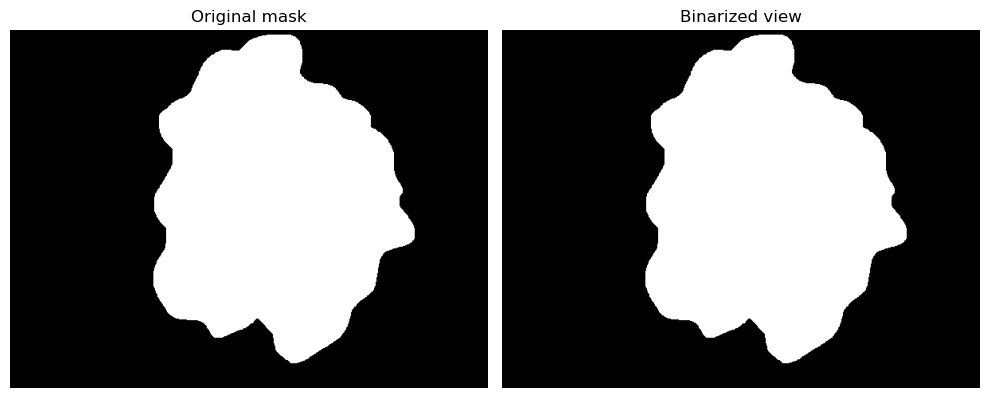

In [1]:
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


ROOT = Path("..")
DATA_ROOT = ROOT / "data"
MASK_DIR = DATA_ROOT / "HAM10000_segmentations_lesion_tschandl"
mask_path = MASK_DIR / "ISIC_0024306_segmentation.png"

# load mask as grayscale

mask_img = Image.open(mask_path).convert("L")
mask_np = np.array(mask_img)
print("Mask path:", mask_path)
print("Shape:", mask_np.shape)
print("Dtype:", mask_np.dtype)
print("Min:", mask_np.min(), "Max:", mask_np.max())

unique_vals = np.unique(mask_np)
print("Unique values:", unique_vals[:20], "..." if len(unique_vals) > 20 else "")

# strict binary check
is_binary_01 = np.array_equal(unique_vals, np.array([0, 1])) or np.array_equal(unique_vals, np.array([0])) or np.array_equal(unique_vals, np.array([1]))
is_binary_0255 = np.array_equal(unique_vals, np.array([0, 255])) or np.array_equal(unique_vals, np.array([0])) or np.array_equal(unique_vals, np.array([255]))
print("Binary {0,1} mask?:", is_binary_01)
print("Binary {0,255} mask?:", is_binary_0255)

# if mask is 0/255, convert to 0/1 for inspection

if is_binary_0255:
    mask_bin = (mask_np > 0).astype(np.uint8)
else:
    mask_bin = mask_np
print("Unique values after optional binarization:", np.unique(mask_bin))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(mask_np, cmap="gray")
plt.title("Original mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask_bin, cmap="gray", vmin=0, vmax=1)
plt.title("Binarized view")
plt.axis("off")
plt.tight_layout()

plt.show()

In [2]:
# lesion coverage
lesion_pixels = (mask_bin == 1).sum()
background_pixels = (mask_bin == 0).sum()
total_pixels = mask_bin.size

print("Lesion pixels:", lesion_pixels)
print("Background pixels:", background_pixels)
print("Lesion ratio:", lesion_pixels / total_pixels)

Lesion pixels: 92549
Background pixels: 177451
Lesion ratio: 0.34277407407407406


# Data Inspection HAM10000

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

REPO_ROOT = Path("..").resolve()
HAM_ROOT = REPO_ROOT / "data" / "HAM10000"

HAM_CSV = HAM_ROOT / "HAM10000.csv"
MASK_CSV = HAM_ROOT / "ham_segmentation_overlap.csv"

IMAGE_ROOT = HAM_ROOT / "images"
OUT_ROOT = REPO_ROOT / "outputs" / "dataset_overview_clinician"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

CLASS_NAME_MAP = {
    "akiec": "Actinic keratosis / intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesion",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevus",
    "vasc": "Vascular lesion",
}

CLASS_ORDER = ["mel", "nv", "bkl", "bcc", "akiec", "df", "vasc"]

print("HAM_CSV:", HAM_CSV)
print("MASK_CSV:", MASK_CSV)
print("OUT_ROOT:", OUT_ROOT)

HAM_CSV: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/HAM10000.csv
MASK_CSV: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/ham_segmentation_overlap.csv
OUT_ROOT: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician


In [2]:
df = pd.read_csv(HAM_CSV)

print("Rows:", len(df))
print("Columns:")
print(df.columns.tolist())

required_cols = ["image_id", "dx", "split", "label", "image"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

display(df.head())

Rows: 10015
Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'split', 'label', 'image', 'binary_label', 'age_group']


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,split,label,image,binary_label,age_group
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0027419.jpg,0,old
1,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0026769.jpg,0,old
2,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0025661.jpg,0,old
3,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0031633.jpg,0,old
4,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0027850.jpg,0,old


Total images: 10015


,split,count,percent
0,train,8207,81.947079
1,test,1232,12.301548
2,val,575,5.741388
3,trainisic,1,0.009985


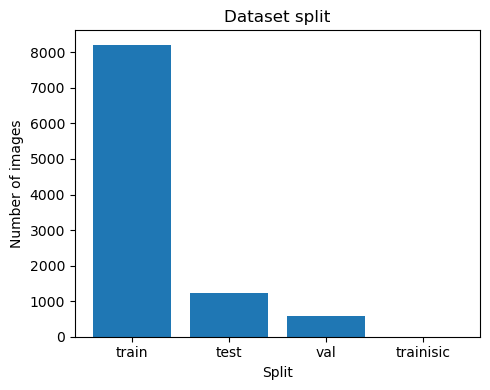

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/dataset_split_counts.png


In [3]:
split_counts = df["split"].value_counts().rename_axis("split").reset_index(name="count")
split_counts["percent"] = 100 * split_counts["count"] / split_counts["count"].sum()

print("Total images:", len(df))
display(split_counts)

plt.figure(figsize=(5, 4))
plt.bar(split_counts["split"], split_counts["count"])
plt.title("Dataset split")
plt.ylabel("Number of images")
plt.xlabel("Split")
plt.tight_layout()

split_plot_path = OUT_ROOT / "dataset_split_counts.png"
plt.savefig(split_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", split_plot_path)

,class_code,class_name,count,percent
0,mel,Melanoma,1113,11.113330
1,nv,Melanocytic nevus,6705,66.949576
2,bkl,Benign keratosis-like lesion,1099,10.973540
3,bcc,Basal cell carcinoma,514,5.132302
4,akiec,Actinic keratosis / intraepithelial carcinoma,327,3.265102
5,df,Dermatofibroma,115,1.148278
6,vasc,Vascular lesion,142,1.417873


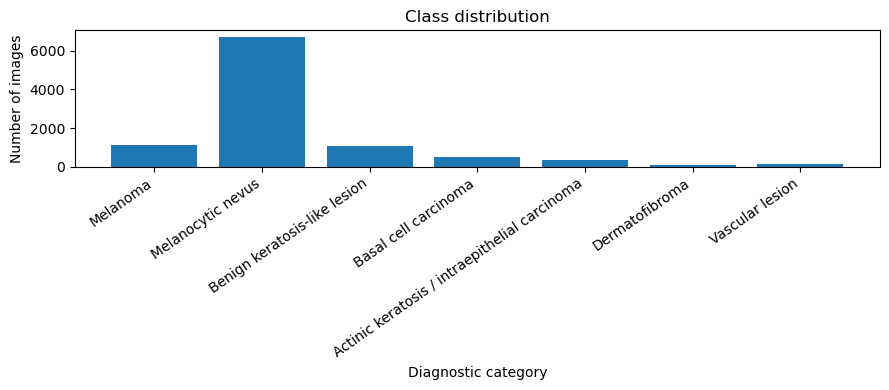

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/class_distribution.png


In [4]:
class_counts = (
    df["dx"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .rename_axis("class_code")
    .reset_index(name="count")
)

class_counts["class_name"] = class_counts["class_code"].map(CLASS_NAME_MAP)
class_counts["percent"] = 100 * class_counts["count"] / class_counts["count"].sum()

display(class_counts[["class_code", "class_name", "count", "percent"]])

plt.figure(figsize=(9, 4))
plt.bar(class_counts["class_name"], class_counts["count"])
plt.title("Class distribution")
plt.ylabel("Number of images")
plt.xlabel("Diagnostic category")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

class_plot_path = OUT_ROOT / "class_distribution.png"
plt.savefig(class_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", class_plot_path)

split,test,train,trainisic,val,class_name
dx,,,,,
mel,70,1021,0,22,Melanoma
nv,951,5304,0,450,Melanocytic nevus
bkl,107,941,1,50,Benign keratosis-like lesion
bcc,44,448,0,22,Basal cell carcinoma
akiec,35,273,0,19,Actinic keratosis / intraepithelial carcinoma
df,8,102,0,5,Dermatofibroma
vasc,17,118,0,7,Vascular lesion


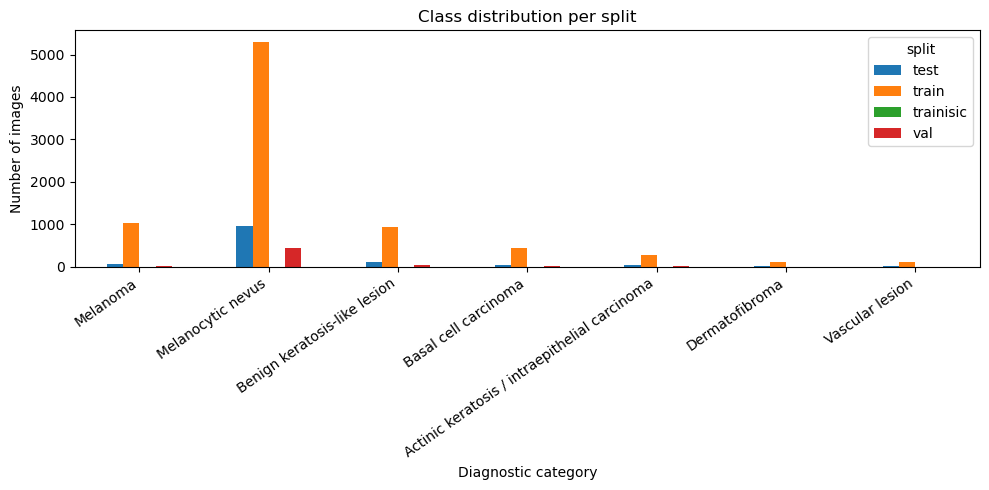

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/class_distribution_by_split.png


In [5]:
split_class_counts = (
    df.groupby(["split", "dx"])
    .size()
    .reset_index(name="count")
)

pivot_split_class = split_class_counts.pivot(index="dx", columns="split", values="count").fillna(0).astype(int)
pivot_split_class = pivot_split_class.reindex(CLASS_ORDER)
pivot_split_class["class_name"] = pivot_split_class.index.map(CLASS_NAME_MAP)

display(pivot_split_class)

plot_df = pivot_split_class.drop(columns=["class_name"], errors="ignore")

plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Class distribution per split")
plt.ylabel("Number of images")
plt.xlabel("Diagnostic category")
plt.xticks(
    ticks=range(len(plot_df.index)),
    labels=[CLASS_NAME_MAP[x] for x in plot_df.index],
    rotation=35,
    ha="right",
)
plt.tight_layout()

split_class_plot_path = OUT_ROOT / "class_distribution_by_split.png"
plt.savefig(split_class_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", split_class_plot_path)

In [6]:
if MASK_CSV.exists():
    mask_df = pd.read_csv(MASK_CSV)
    print("Mask CSV columns:")
    print(mask_df.columns.tolist())
    display(mask_df.head())

    # Adjust if your mask CSV uses different names
    possible_id_cols = ["image_id", "image", "isic_id"]
    id_col = next((c for c in possible_id_cols if c in mask_df.columns), None)

    if id_col is None:
        raise ValueError("Could not find image id column in mask CSV.")

    if "mask_rel_path" not in mask_df.columns:
        raise ValueError("Expected mask_rel_path column in mask CSV.")

    df_vis = df.merge(
        mask_df[[id_col, "mask_rel_path"]],
        left_on="image_id",
        right_on=id_col,
        how="left",
    )

    if id_col != "image_id":
        df_vis = df_vis.drop(columns=[id_col])

    df_vis["mask_found"] = df_vis["mask_rel_path"].notna()
else:
    print("[WARN] No mask CSV found. Example images will be shown without lesion outline.")
    df_vis = df.copy()
    df_vis["mask_rel_path"] = np.nan
    df_vis["mask_found"] = False

print("Rows with masks:", df_vis["mask_found"].sum())
display(df_vis.head())

Mask CSV columns:
['image_id', 'label', 'dx', 'split', 'image_rel_path', 'mask_rel_path', 'mask_found']


,image_id,label,dx,split,image_rel_path,mask_rel_path,mask_found
0,ISIC_0027419,2,bkl,train,images/ISIC_0027419.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1
1,ISIC_0026769,2,bkl,train,images/ISIC_0026769.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1
2,ISIC_0025661,2,bkl,train,images/ISIC_0025661.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1
3,ISIC_0031633,2,bkl,train,images/ISIC_0031633.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1
4,ISIC_0027850,2,bkl,train,images/ISIC_0027850.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1


Rows with masks: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,split,label,image,binary_label,age_group,mask_rel_path,mask_found
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0027419.jpg,0,old,../HAM10000_segmentations_lesion_tschandl/ISIC...,True
1,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0026769.jpg,0,old,../HAM10000_segmentations_lesion_tschandl/ISIC...,True
2,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0025661.jpg,0,old,../HAM10000_segmentations_lesion_tschandl/ISIC...,True
3,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0031633.jpg,0,old,../HAM10000_segmentations_lesion_tschandl/ISIC...,True
4,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0027850.jpg,0,old,../HAM10000_segmentations_lesion_tschandl/ISIC...,True


In [7]:
def resolve_image_path(row):
    image_value = str(row["image"])
    p = Path(image_value)

    if p.is_absolute():
        return p

    # Case 1: image column is just ISIC_xxx.jpg
    candidate = IMAGE_ROOT / image_value
    if candidate.exists():
        return candidate

    # Case 2: image column already contains images/ISIC_xxx.jpg
    candidate = HAM_ROOT / image_value
    if candidate.exists():
        return candidate

    # Fallback
    return IMAGE_ROOT / f"{row['image_id']}.jpg"


def resolve_mask_path(row):
    mask_value = row.get("mask_rel_path", np.nan)

    if pd.isna(mask_value):
        return None

    p = Path(str(mask_value))

    if p.is_absolute():
        return p

    candidate = HAM_ROOT / p
    if candidate.exists():
        return candidate

    candidate = REPO_ROOT / p
    if candidate.exists():
        return candidate

    return HAM_ROOT / p


def load_rgb(path, size=224):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size))
    return np.array(img)


def overlay_mask_outline(rgb_uint8, mask_path, thickness=2):
    if mask_path is None or not Path(mask_path).exists():
        return rgb_uint8

    mask = Image.open(mask_path).convert("L").resize(
        (rgb_uint8.shape[1], rgb_uint8.shape[0]),
        resample=Image.Resampling.NEAREST,
    )
    mask_np = np.array(mask)
    mask_bin = (mask_np > 0).astype(np.uint8)

    out = rgb_uint8.copy()
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(out, contours, -1, color=(255, 0, 0), thickness=thickness)

    return out

In [8]:
examples = []

for cls in CLASS_ORDER:
    cls_df = df_vis[(df_vis["dx"] == cls) & (df_vis["split"] == "test")].copy()

    if len(cls_df) == 0:
        cls_df = df_vis[df_vis["dx"] == cls].copy()

    # Prefer examples with masks
    cls_masked = cls_df[cls_df["mask_found"] == True].copy()
    if len(cls_masked) > 0:
        selected = cls_masked.sample(n=1, random_state=42).iloc[0]
    else:
        selected = cls_df.sample(n=1, random_state=42).iloc[0]

    examples.append(selected)

example_df = pd.DataFrame(examples)

display(example_df[["image_id", "dx", "split", "image", "mask_rel_path", "mask_found"]])

,image_id,dx,split,image,mask_rel_path,mask_found
8922,ISIC_0027776,mel,test,ISIC_0027776.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,True
9228,ISIC_0027082,nv,test,ISIC_0027082.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,True
8860,ISIC_0030998,bkl,test,ISIC_0030998.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,True
9024,ISIC_0029545,bcc,test,ISIC_0029545.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,True
10006,ISIC_0026132,akiec,test,ISIC_0026132.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,True
8892,ISIC_0026471,df,test,ISIC_0026471.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,True
8970,ISIC_0029889,vasc,test,ISIC_0029889.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,True


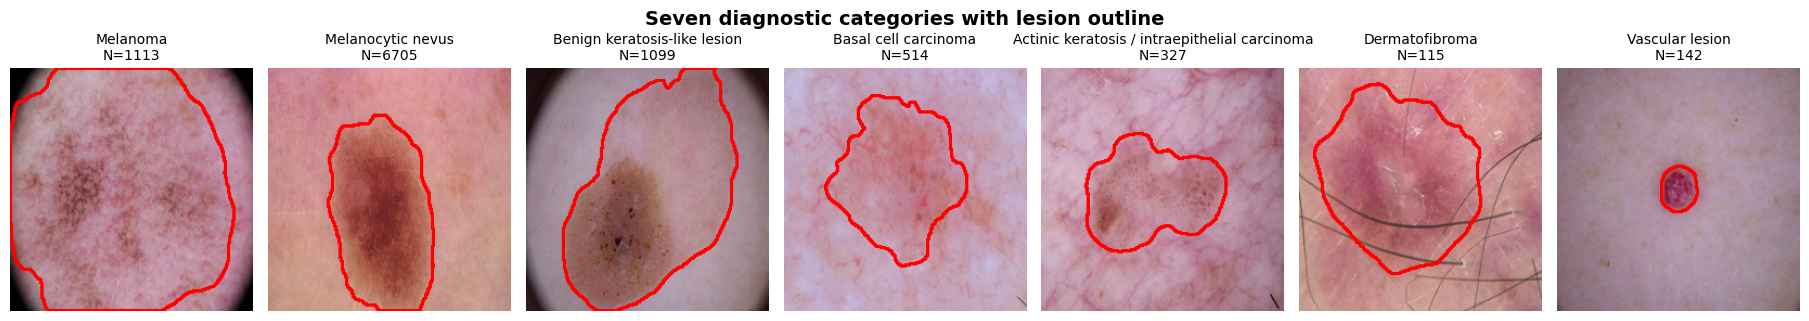

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/seven_classes_examples_with_outline.png


In [9]:
n = len(example_df)
fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3.4))

if n == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, example_df.iterrows()):
    img_path = resolve_image_path(row)
    mask_path = resolve_mask_path(row)

    rgb = load_rgb(img_path, size=224)
    rgb_overlay = overlay_mask_outline(rgb, mask_path)

    cls_code = row["dx"]
    cls_name = CLASS_NAME_MAP.get(cls_code, cls_code)

    count = int(class_counts[class_counts["class_code"] == cls_code]["count"].iloc[0])

    ax.imshow(rgb_overlay)
    ax.set_title(f"{cls_name}\nN={count}", fontsize=10)
    ax.axis("off")

plt.suptitle("Seven diagnostic categories with lesion outline", fontsize=14, fontweight="bold")
plt.tight_layout()

examples_path = OUT_ROOT / "seven_classes_examples_with_outline.png"
plt.savefig(examples_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", examples_path)

Age summary:


count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64

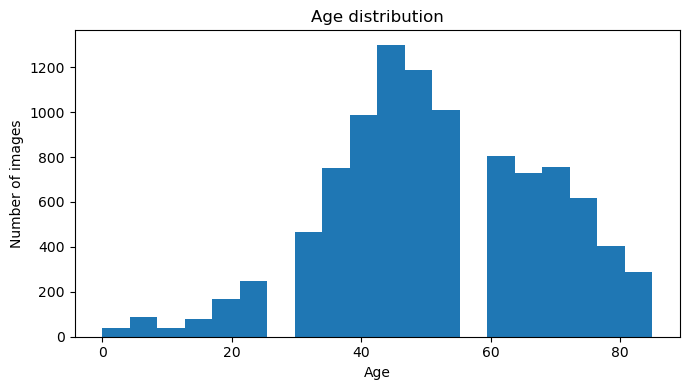

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/age_distribution.png


,age_group,count,percent
0,medium,4935,49.276086
1,old,4611,46.040939
2,young,412,4.113829
3,unknown,57,0.569146


In [10]:
if "age" in df.columns:
    age_df = df.dropna(subset=["age"]).copy()

    print("Age summary:")
    display(age_df["age"].describe())

    plt.figure(figsize=(7, 4))
    plt.hist(age_df["age"], bins=20)
    plt.title("Age distribution")
    plt.xlabel("Age")
    plt.ylabel("Number of images")
    plt.tight_layout()

    age_plot_path = OUT_ROOT / "age_distribution.png"
    plt.savefig(age_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", age_plot_path)

if "age_group" in df.columns:
    age_group_counts = df["age_group"].value_counts().rename_axis("age_group").reset_index(name="count")
    age_group_counts["percent"] = 100 * age_group_counts["count"] / age_group_counts["count"].sum()

    display(age_group_counts)

Age summary:


count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64

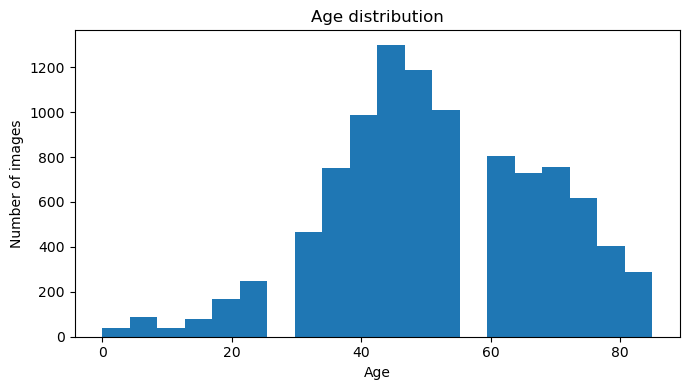

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/age_distribution.png


,age_group,count,percent
0,medium,4935,49.276086
1,old,4611,46.040939
2,young,412,4.113829
3,unknown,57,0.569146


In [11]:
if "age" in df.columns:
    age_df = df.dropna(subset=["age"]).copy()

    print("Age summary:")
    display(age_df["age"].describe())

    plt.figure(figsize=(7, 4))
    plt.hist(age_df["age"], bins=20)
    plt.title("Age distribution")
    plt.xlabel("Age")
    plt.ylabel("Number of images")
    plt.tight_layout()

    age_plot_path = OUT_ROOT / "age_distribution.png"
    plt.savefig(age_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", age_plot_path)

if "age_group" in df.columns:
    age_group_counts = df["age_group"].value_counts().rename_axis("age_group").reset_index(name="count")
    age_group_counts["percent"] = 100 * age_group_counts["count"] / age_group_counts["count"].sum()

    display(age_group_counts)

,sex,count,percent
0,male,5406,53.979031
1,female,4552,45.451822
2,unknown,57,0.569146


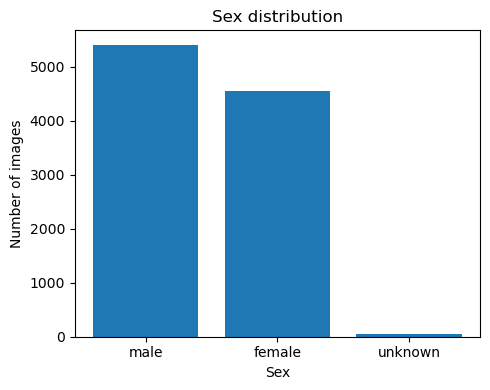

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/sex_distribution.png


In [12]:
if "sex" in df.columns:
    sex_counts = df["sex"].fillna("unknown").value_counts().rename_axis("sex").reset_index(name="count")
    sex_counts["percent"] = 100 * sex_counts["count"] / sex_counts["count"].sum()

    display(sex_counts)

    plt.figure(figsize=(5, 4))
    plt.bar(sex_counts["sex"], sex_counts["count"])
    plt.title("Sex distribution")
    plt.ylabel("Number of images")
    plt.xlabel("Sex")
    plt.tight_layout()

    sex_plot_path = OUT_ROOT / "sex_distribution.png"
    plt.savefig(sex_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", sex_plot_path)

,localization,count,percent
0,back,2192,21.887169
1,lower extremity,2077,20.738892
2,trunk,1404,14.018972
3,upper extremity,1118,11.163255
4,abdomen,1022,10.204693
5,face,745,7.438842
6,chest,407,4.063904
7,foot,319,3.185222
8,unknown,234,2.336495
9,neck,168,1.677484


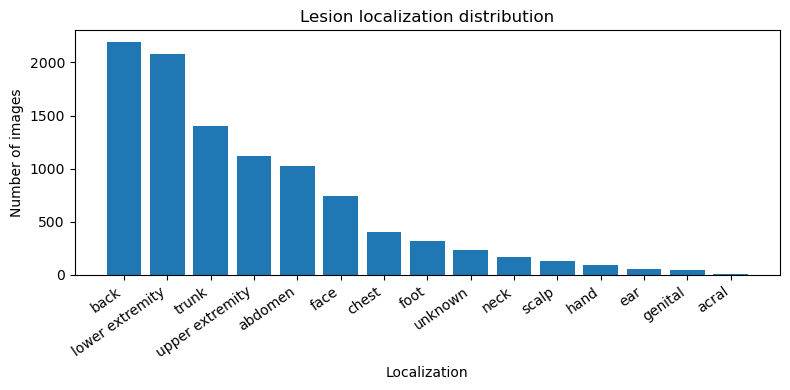

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/localization_distribution.png


In [13]:
if "localization" in df.columns:
    loc_counts = (
        df["localization"]
        .fillna("unknown")
        .value_counts()
        .rename_axis("localization")
        .reset_index(name="count")
    )
    loc_counts["percent"] = 100 * loc_counts["count"] / loc_counts["count"].sum()

    display(loc_counts)

    plt.figure(figsize=(8, 4))
    plt.bar(loc_counts["localization"], loc_counts["count"])
    plt.title("Lesion localization distribution")
    plt.ylabel("Number of images")
    plt.xlabel("Localization")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()

    loc_plot_path = OUT_ROOT / "localization_distribution.png"
    plt.savefig(loc_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", loc_plot_path)

In [14]:
total_n = len(df)

split_text = split_counts.copy()
split_text["text"] = split_text.apply(
    lambda r: f"{r['split']}: {int(r['count'])} ({r['percent']:.1f}%)",
    axis=1,
)

class_text = class_counts.copy()
class_text["text"] = class_text.apply(
    lambda r: f"{r['class_name']}: {int(r['count'])} ({r['percent']:.1f}%)",
    axis=1,
)

print("=" * 80)
print("SLIDE SUMMARY")
print("=" * 80)
print(f"Total images: {total_n}")
print("\nSplits:")
for x in split_text["text"]:
    print("-", x)

print("\nClasses:")
for x in class_text["text"]:
    print("-", x)

print("\nSaved figures:")
for p in sorted(OUT_ROOT.glob("*.png")):
    print("-", p)

SLIDE SUMMARY
Total images: 10015

Splits:
- train: 8207 (81.9%)
- test: 1232 (12.3%)
- val: 575 (5.7%)
- trainisic: 1 (0.0%)

Classes:
- Melanoma: 1113 (11.1%)
- Melanocytic nevus: 6705 (66.9%)
- Benign keratosis-like lesion: 1099 (11.0%)
- Basal cell carcinoma: 514 (5.1%)
- Actinic keratosis / intraepithelial carcinoma: 327 (3.3%)
- Dermatofibroma: 115 (1.1%)
- Vascular lesion: 142 (1.4%)

Saved figures:
- /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/age_distribution.png
- /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/class_distribution.png
- /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/class_distribution_by_split.png
- /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/dataset_split_counts.png
- /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/dataset_overview_clinician/localization_distribution.png
- /Users/

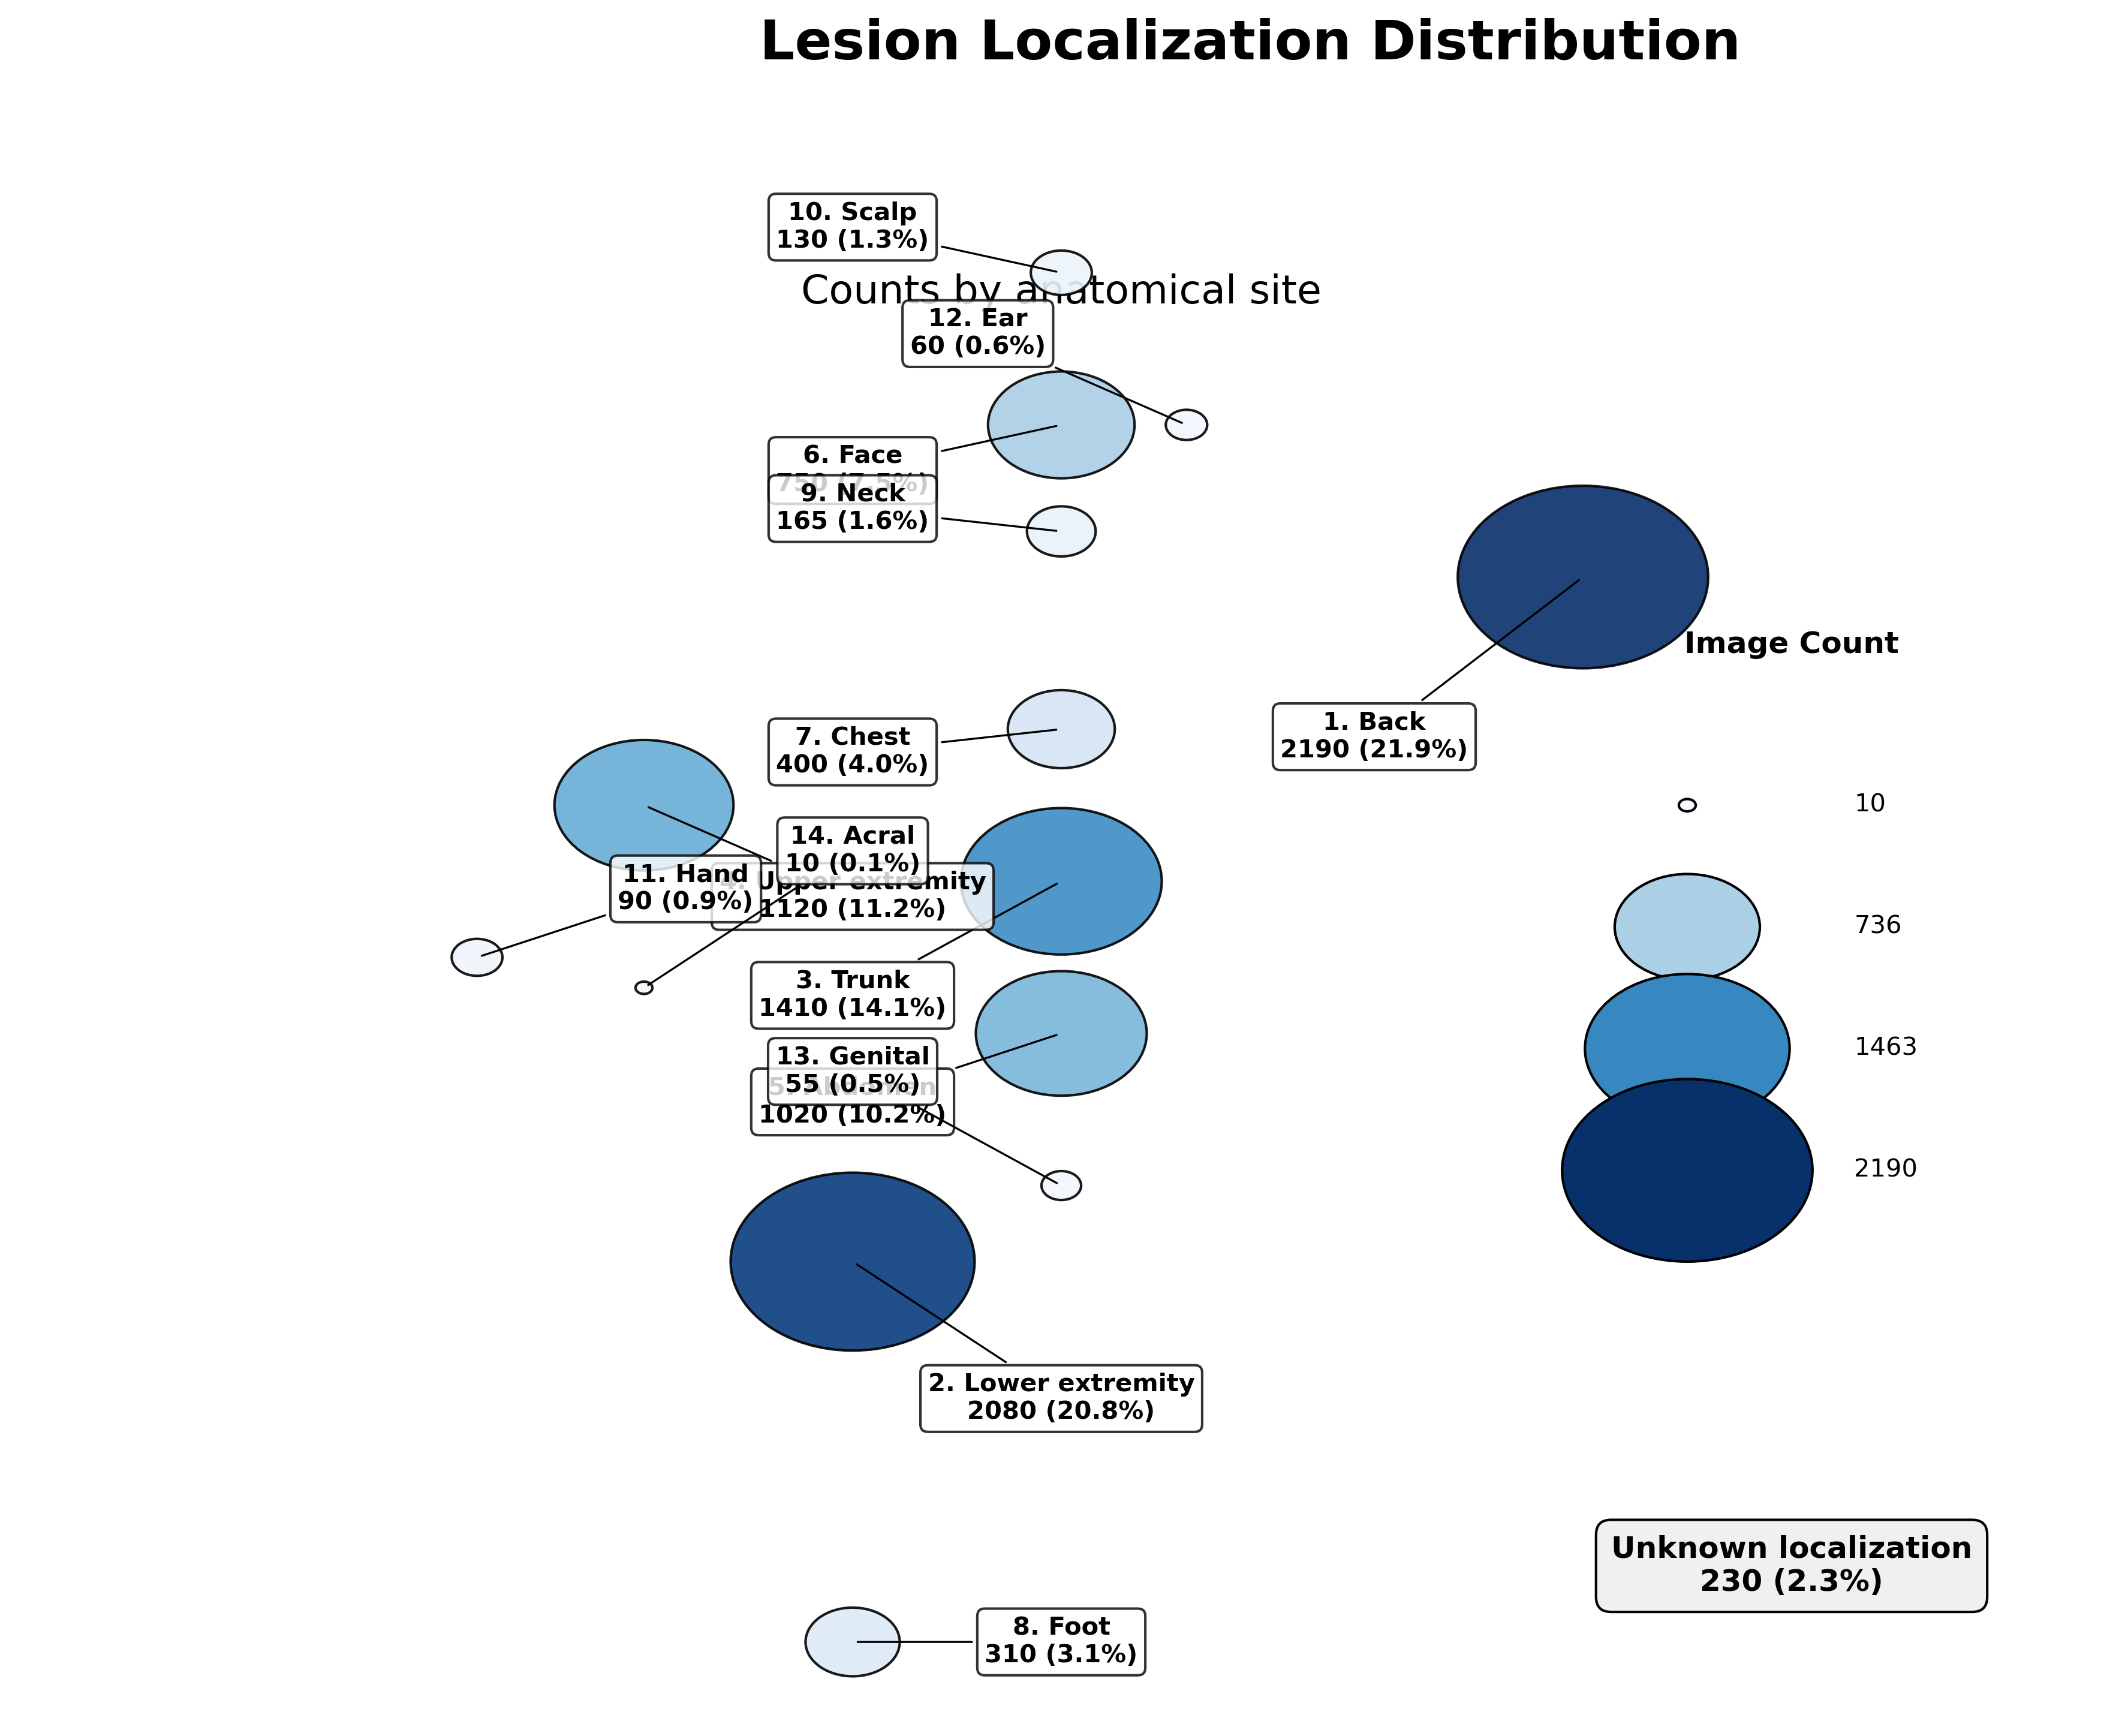

Total known: 9790
Total cases: 10020


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection

# 1. Provide Data
data = {
    'localization': [
        'back', 'lower extremity', 'trunk', 'upper extremity', 'abdomen',
        'face', 'chest', 'foot', 'neck', 'scalp', 'hand', 'ear', 'genital', 'acral'
    ],
    'count': [2190, 2080, 1410, 1120, 1020, 750, 400, 310, 165, 130, 90, 60, 55, 10]
}
unknown_count = 230

# 2. Prepare Data
df = pd.DataFrame(data)
total_known = df['count'].sum()
df['percentage'] = (df['count'] / (total_known + unknown_count) * 100).round(1)

# Sort by count (descending) for coloring/numbering
df = df.sort_values(by='count', ascending=False).reset_index(drop=True)
df['rank'] = df.index + 1

# Define specific anatomical points (x, y) on a generic 0-100 coordinate system
# For a production version, these should map to your silhouette image coordinates.
points = {
    'back': (75, 75),  # Map to posterior figure
    'lower extremity': (40, 30),
    'trunk': (50, 55),
    'upper extremity': (30, 60),
    'abdomen': (50, 45),
    'face': (50, 85),
    'chest': (50, 65),
    'foot': (40, 5),
    'neck': (50, 78),
    'scalp': (50, 95),
    'hand': (22, 50),
    'ear': (56, 85),
    'genital': (50, 35),
    'acral': (30, 48) # example point on fingers
}

# 3. Setup Plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_axis_off()

# Set Titles
plt.suptitle('Lesion Localization Distribution', fontsize=22, fontweight='bold', y=0.96)
plt.title('Counts by anatomical site', fontsize=16, y=0.92)

# Color and Size scaling
norm = plt.Normalize(df['count'].min(), df['count'].max())
cmap = cm.Blues # Sequential color scale

# Calculate circle areas proportional to count (pi * r^2 = k*count)
# We want to map counts to radius. Radius proportional to sqrt(count)
max_r = 6
df['radius'] = max_r * np.sqrt(df['count'] / df['count'].max())

# 4. Plot Anatomical Points and Labels
patches = []
label_data = []

# Iteratively plot each ranked location
for i, row in df.iterrows():
    loc = row['localization']
    if loc in points:
        coords = points[loc]
        color = cmap(norm(row['count']))
        
        # Create circle patches
        circle = Circle(coords, row['radius'], facecolor=color, edgecolor='black', linewidth=1, alpha=0.9, zorder=10)
        ax.add_patch(circle)
        
        # Create leader line (placeholder vector)
        label_offset_x = 10 if coords[0] < 50 else -10
        label_x = coords[0] + label_offset_x
        label_y = coords[1] + (i * 1.5 - len(df)*0.75) # Spread out labels vertically

        ax.annotate(
            f"{row['rank']}. {loc.capitalize()}\n{row['count']} ({row['percentage']}%)",
            xy=coords, xycoords='data',
            xytext=(label_x, label_y), textcoords='data',
            fontsize=10, fontweight='bold', color='black',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1, alpha=0.8),
            arrowprops=dict(arrowstyle="-", color="black", linewidth=0.8),
            ha='center', va='center', zorder=11
        )

# 5. Add Legend and Unknown Box
# Unknown localization box
unknown_text = f"Unknown localization\n{unknown_count} ({(unknown_count / (total_known + unknown_count) * 100).round(1)}%)"
ax.text(85, 10, unknown_text, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", fc="#f0f0f0", ec="black", lw=1),
        ha='center', va='center')

# Visual encoding legend (size and color)
legend_x = 85
legend_y_start = 60
num_legend_steps = 4
count_steps = np.linspace(df['count'].min(), df['count'].max(), num_legend_steps)

ax.text(legend_x, legend_y_start + 10, "Image Count", fontsize=12, fontweight='bold', ha='center')

for i, val in enumerate(count_steps):
    val = int(val)
    # Calculate radius for this value on the scale
    r = max_r * np.sqrt(val / df['count'].max())
    color = cmap(norm(val))
    
    y = legend_y_start - (i * 8)
    
    # Draw example circle
    circle_leg = Circle((legend_x - 5, y), r, facecolor=color, edgecolor='black', linewidth=1)
    ax.add_patch(circle_leg)
    
    # Label the step
    ax.text(legend_x + 3, y, f"{val}", fontsize=10, va='center')

plt.tight_layout(rect=[0, 0, 0.85, 0.92]) # Make room for legend/unknown box
plt.savefig('lesion_distribution_code.png', bbox_inches='tight')
plt.show()

print(f"Total known: {total_known}")
print(f"Total cases: {total_known + unknown_count}")